<a href="https://colab.research.google.com/github/MrithikaDutta/DS_Deep_Learning/blob/main/LAB_performance_424.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow import keras

In [ ]:
(x_train, y_train), (x_test, y_test)=keras.datasets.california_housing.load_data(
    version="large", path="california_housing.npz", test_split=0.2, seed=113
)

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers


model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='rmsprop', loss='mean_squared_error', metrics=['mean_absolute_error'])
history = model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1)

Epoch 1/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 18009653248.0000 - mean_absolute_error: 96643.1641 - val_loss: 15121438720.0000 - val_mean_absolute_error: 90973.9375
Epoch 2/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13965911040.0000 - mean_absolute_error: 88029.6406 - val_loss: 11973906432.0000 - val_mean_absolute_error: 84910.2266
Epoch 3/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11862784000.0000 - mean_absolute_error: 84610.5156 - val_loss: 11299962880.0000 - val_mean_absolute_error: 83134.4297
Epoch 4/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11496967168.0000 - mean_absolute_error: 83550.1094 - val_loss: 11079364608.0000 - val_mean_absolute_error: 82338.8594
Epoch 5/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11543554048.0000 - mean_absolute_error: 83859.1250 - val_loss: 11028762624.0000 - val_mean_absolute_error: 81792.3281
Epoch 6/50
233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 11101425664.0000 - mean_absolute_error: 82446.9609

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error (MAE): {mae}')

r2 = r2_score(y_test, y_pred)
print(f'R-squared (R2 Score): {r2}')

Mean Absolute Error (MAE): 96373.34375
R-squared (R2 Score): -0.3513752222061157


In [ ]:
tolerance_percentage = 0.10  # 10% tolerance
absolute_percentage_errors = np.abs((y_test - y_pred.flatten()) / y_test)
accurate_predictions = absolute_percentage_errors <= tolerance_percentage
custom_accuracy = np.mean(accurate_predictions) * 100
print(f'Custom Accuracy (within {tolerance_percentage*100}% of true value): {custom_accuracy:.2f}%')

Custom Accuracy (within 10.0% of true value): 11.72%


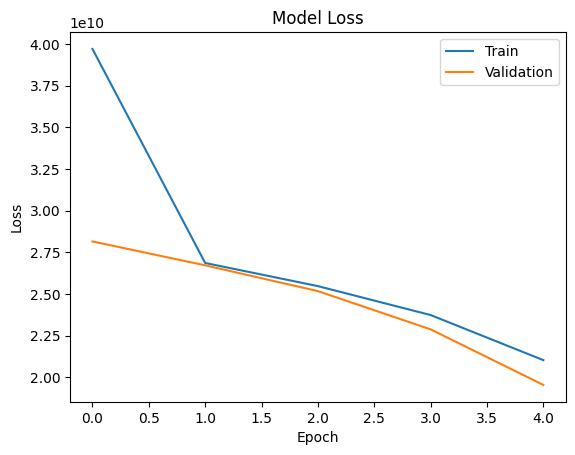

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper right')
plt.show()